In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\jijes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

RESULTS_DIR = "../results/accuracy"
PLOTS_DIR   = "../plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [6]:
# Load accuracy JSONs
# Each file has scores for all 5 benchmarks
import glob

def load_eval(model_name):
    pattern = f"{RESULTS_DIR}/{model_name}_eval_*.json"
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No file matching {pattern}")
    with open(matches[0]) as f:
        data = json.load(f)
    r = data["results"]
    return {
        "mmlu":       r["mmlu"]["acc,none"],
        "hellaswag":  r["hellaswag"]["acc_norm,none"],
        "gsm8k":      r["gsm8k"]["exact_match,strict-match"],
        "humaneval":  r["humaneval"]["pass@1,create_test"],
        "truthfulqa": r["truthfulqa_mc1"]["acc,none"],
    }

scores = {
    "fp16": load_eval("fp16"),
    "int8": load_eval("int8"),
    "gptq": load_eval("gptq"),
    "awq":  load_eval("awq"),
}

accuracy_df = pd.DataFrame(scores).T
accuracy_df.index.name = "model"
print(accuracy_df.round(3))

        mmlu  hellaswag  gsm8k  humaneval  truthfulqa
model                                                
fp16   0.683      0.801  0.713      0.604       0.379
int8   0.680      0.798  0.710      0.622       0.382
gptq   0.665      0.792  0.657      0.537       0.381
awq    0.662      0.794  0.723      0.604       0.375


In [7]:
# Accuracy table
# Clean formatted table showing all scores
print("\nAccuracy Scores (higher is better):")
print(accuracy_df.round(3).to_string())


Accuracy Scores (higher is better):
        mmlu  hellaswag  gsm8k  humaneval  truthfulqa
model                                                
fp16   0.683      0.801  0.713      0.604       0.379
int8   0.680      0.798  0.710      0.622       0.382
gptq   0.665      0.792  0.657      0.537       0.381
awq    0.662      0.794  0.723      0.604       0.375


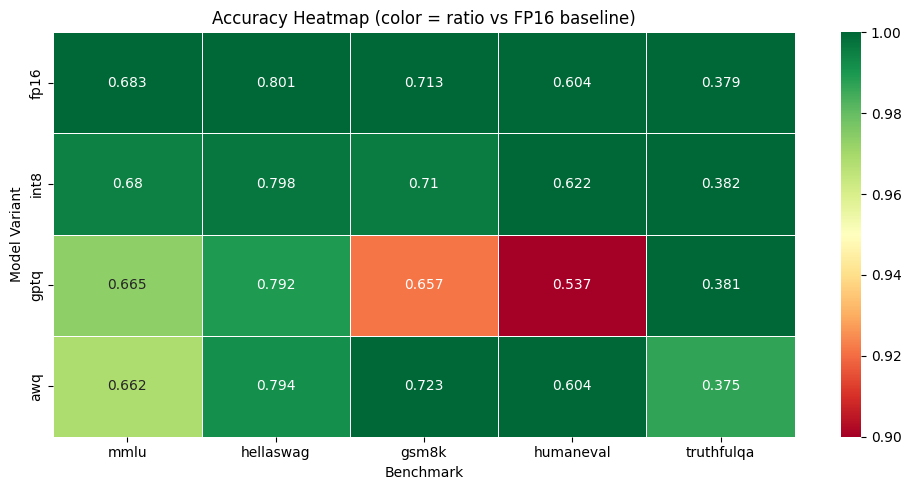

Saved accuracy_heatmap.png


In [8]:
# Accuracy heatmap
# Color coded — green = close to FP16, red = degraded
# Normalize each column relative to FP16 baseline
fp16_scores  = accuracy_df.loc["fp16"]
degradation  = accuracy_df.div(fp16_scores) # ratio vs FP16

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    degradation,
    annot=accuracy_df.round(3),  # show actual scores in cells
    fmt="",
    cmap="RdYlGn",
    vmin=0.90,
    vmax=1.0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Accuracy Heatmap (color = ratio vs FP16 baseline)")
ax.set_xlabel("Benchmark")
ax.set_ylabel("Model Variant")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/accuracy_heatmap.png", dpi=150)
plt.show()
print("Saved accuracy_heatmap.png")

In [9]:
# Degradation table
# How many points each variant lost vs FP16
degradation_pts = accuracy_df.subtract(fp16_scores)
print("\nAccuracy Degradation vs FP16 (negative = worse):")
print(degradation_pts.round(3).to_string())


Accuracy Degradation vs FP16 (negative = worse):
        mmlu  hellaswag  gsm8k  humaneval  truthfulqa
model                                                
fp16   0.000      0.000  0.000      0.000       0.000
int8  -0.004     -0.003 -0.003      0.018       0.002
gptq  -0.018     -0.008 -0.056     -0.067       0.001
awq   -0.021     -0.007  0.011      0.000      -0.005


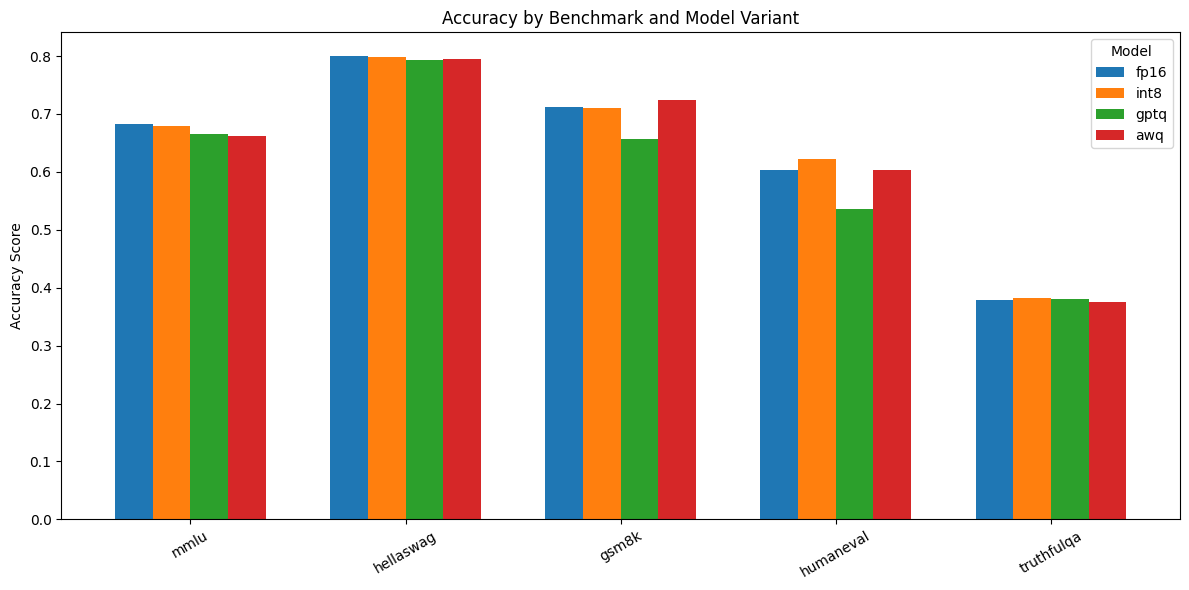

Saved accuracy_by_benchmark.png


In [10]:
# Per benchmark bar chart
# Side by side bars for all models, one group per benchmark
fig, ax = plt.subplots(figsize=(12, 6))
accuracy_df.T.plot(kind="bar", ax=ax, width=0.7)
ax.set_ylabel("Accuracy Score")
ax.set_title("Accuracy by Benchmark and Model Variant")
ax.set_xticklabels(accuracy_df.columns, rotation=30)
ax.legend(title="Model")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/accuracy_by_benchmark.png", dpi=150)
plt.show()
print("Saved accuracy_by_benchmark.png")